# Covariance inversion benchmark

In a probabilistic model, we have to inverse covariance matrices very often. This is made simpler by the fact that covariance matrices are positive-definite and symmetrix. The most efficient way to compute the inverse of a covariance matrix is to use Cholesky decomposition, which is numerically stable and efficient.

As Jax implements the APIs from numpy, scipy and lax, we are provided with a set of functions to compute the inverse of a covariance matrix, with slight differences in inputs/outputs/performances. In this benchmark, we will compare the performance of these functions on a set of covariance matrices.

**Options for cholesky decomposition:**
* `jax.scipy.linalg.cho_factor`
* `jax.scipy.linalg.cholesky`
* `jax.lax.linalg.cholesky`
* `jax.numpy.linalg.cholesky`

***Options for solving linear systems:**
* `jax.scipy.linalg.cho_solve`
* `jax.scipy.linalg.solve_triangular`
* `jax.lax.linalg.triangular_solve`


`jax.numpy.linalg.solve` and `jax.scipy.linalg.solve` are not used here, as they are not designed for triangular matrices and are less efficient than the other options.

---

## Setup

In [1]:
USE_JIT = True
USE_X64 = False
DEBUG_NANS = False
VERBOSE = False

In [2]:
import os
os.environ['JAX_ENABLE_X64'] = str(USE_X64).lower()

In [3]:
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)

In [4]:
from jax import random, jit, vmap
import jax.numpy as jnp
import jax.lax as jlx
import jax.scipy as jsp
import matplotlib.pyplot as plt
import numpy as np
import timeit

In [5]:
from Kernax import RBFKernel

## Data generation

In [6]:
key = random.PRNGKey(42)

In [7]:
key, subkey = random.split(key)

inputs = random.uniform(subkey, (250, 200, 5))  # 250 tasks, 200 samples, 5 features

In [8]:
kern = RBFKernel(length_scale=jnp.array(0.3), variance=jnp.array(1.))

In [9]:
covs = kern(inputs)
covs.shape

(250, 200, 200)

In [10]:
# Dictionary to store timing results
timing_results = {}

def benchmark_function(func, *args, name=None, number=25, repeat=5):
    """Benchmark a function and store results"""
    # Warm up
    func(*args).block_until_ready()
    
    # Time the function
    times = []
    for _ in range(repeat):
        start = timeit.default_timer()
        for _ in range(number):
            result = func(*args)
            result.block_until_ready()
        end = timeit.default_timer()
        times.append((end - start) / number)
    
    mean_time = np.mean(times) * 1000  # Convert to milliseconds
    std_time = np.std(times) * 1000
    
    if name:
        timing_results[name] = {'mean': mean_time, 'std': std_time}
    
    return mean_time, std_time

---

## Baseline : numpy inv

In [11]:
@jit
def numpy_inv(cov):
	"""Compute the inverse of a covariance matrix using numpy's inv."""
	return jnp.linalg.inv(cov)

In [12]:
res_numpy_inv = numpy_inv(covs)

In [13]:
mean_time, std_time = benchmark_function(numpy_inv, covs, name="numpy_inv")
print(f"numpy_inv: {mean_time:.2f} ± {std_time:.2f} ms")

numpy_inv: 56.59 ± 1.12 ms


---

## Scipy's cho_factor

### + scipy's cho_solve

In [14]:
@jit
def scipy_cho_factor_scipy_cho_solve(cov):
	"""Compute the inverse of a covariance matrix using scipy's cho_factor and cho_solve."""
	#U = jsp.linalg.cho_factor(cov)[0]
	#eye = jnp.broadcast_to(jnp.eye(cov.shape[-1]), cov.shape)
	return jsp.linalg.cho_solve(jsp.linalg.cho_factor(cov), jnp.broadcast_to(jnp.eye(cov.shape[-1]), cov.shape))

In [15]:
res_scipy_cho_factor_scipy_cho_solve = scipy_cho_factor_scipy_cho_solve(covs)
jnp.allclose(res_numpy_inv, res_scipy_cho_factor_scipy_cho_solve).item(), jnp.mean(jnp.abs(res_numpy_inv - res_scipy_cho_factor_scipy_cho_solve)).item()

(False, 2.7257822239334928e-06)

In [16]:
mean_time, std_time = benchmark_function(scipy_cho_factor_scipy_cho_solve, covs, name="scipy_cho_factor_scipy_cho_solve")
print(f"scipy_cho_factor_scipy_cho_solve: {mean_time:.2f} ± {std_time:.2f} ms")

scipy_cho_factor_scipy_cho_solve: 44.51 ± 1.08 ms


---

### + scipy's solve_triangular

In [17]:
@jit
def scipy_cho_factor_scipy_solve_triangular(cov):
	"""Compute the inverse of a covariance matrix using scipy's cho_factor and solve_triangular."""
	U = jsp.linalg.cho_factor(cov)[0]
	eye = jnp.broadcast_to(jnp.eye(cov.shape[-1]), cov.shape)
	# First solve U.T * y = I (lower triangular)
	y = jsp.linalg.solve_triangular(jnp.swapaxes(U, -2, -1), eye, lower=True)
	# Then solve U * x = y (upper triangular)
	return jsp.linalg.solve_triangular(U, y, lower=False)

In [18]:
res_cho_factor_scipy_solve_triangular = scipy_cho_factor_scipy_solve_triangular(covs)
jnp.allclose(res_numpy_inv, res_cho_factor_scipy_solve_triangular).item(), jnp.mean(jnp.abs(res_numpy_inv - res_cho_factor_scipy_solve_triangular)).item()

(False, 2.7257822239334928e-06)

In [19]:
mean_time, std_time = benchmark_function(scipy_cho_factor_scipy_solve_triangular, covs, name="scipy_cho_factor_scipy_solve_triangular")
print(f"scipy_cho_factor_scipy_solve_triangular: {mean_time:.2f} ± {std_time:.2f} ms")

scipy_cho_factor_scipy_solve_triangular: 41.60 ± 0.37 ms


---

### + lax's triangular_solve

In [20]:
@jit
def scipy_cho_factor_lax_triangular_solve(cov):
	"""Compute the inverse of a covariance matrix using scipy's cho_factor and lax's triangular_solve."""
	U = jsp.linalg.cho_factor(cov)[0]
	eye = jnp.broadcast_to(jnp.eye(cov.shape[-1]), cov.shape)
	# First solve U.T * y = I (lower triangular)
	y = jlx.linalg.triangular_solve(jnp.swapaxes(U, -2, -1), eye, left_side=True, lower=True)
	# Then solve U * x = y (upper triangular)
	return jlx.linalg.triangular_solve(U, y, left_side=True, lower=False)

In [21]:
res_scipy_cho_factor_lax_triangular_solve = scipy_cho_factor_lax_triangular_solve(covs)
jnp.allclose(res_numpy_inv, res_scipy_cho_factor_lax_triangular_solve).item(), jnp.mean(jnp.abs(res_numpy_inv - res_scipy_cho_factor_lax_triangular_solve)).item()

(False, 2.7257822239334928e-06)

In [22]:
mean_time, std_time = benchmark_function(scipy_cho_factor_lax_triangular_solve, covs, name="scipy_cho_factor_lax_triangular_solve")
print(f"scipy_cho_factor_lax_triangular_solve: {mean_time:.2f} ± {std_time:.2f} ms")

scipy_cho_factor_lax_triangular_solve: 41.98 ± 0.86 ms


---

## Scipy's cholesky

### + scipy's cho_solve

In [23]:
@jit
def scipy_cholesky_scipy_cho_solve(cov):
	"""Compute the inverse of a covariance matrix using scipy's cholesky and cho_solve."""
	U = jsp.linalg.cholesky(cov, lower=True)
	eye = jnp.broadcast_to(jnp.eye(cov.shape[-1]), cov.shape)
	return jsp.linalg.cho_solve((U, True), eye)

In [24]:
res_scipy_cholesky_scipy_cho_solve = scipy_cholesky_scipy_cho_solve(covs)
jnp.allclose(res_numpy_inv, res_scipy_cholesky_scipy_cho_solve).item(), jnp.mean(jnp.abs(res_numpy_inv - res_scipy_cholesky_scipy_cho_solve)).item()

(False, 2.7257822239334928e-06)

In [25]:
mean_time, std_time = benchmark_function(scipy_cholesky_scipy_cho_solve, covs, name="scipy_cholesky_scipy_cho_solve")
print(f"scipy_cholesky_scipy_cho_solve: {mean_time:.2f} ± {std_time:.2f} ms")

scipy_cholesky_scipy_cho_solve: 48.20 ± 0.63 ms


---

### + scipy's solve_triangular

In [26]:
@jit
def scipy_cholesky_scipy_solve_triangular(cov):
	"""Compute the inverse of a covariance matrix using scipy's cholesky and solve_triangular."""
	L = jsp.linalg.cholesky(cov, lower=True)
	eye = jnp.broadcast_to(jnp.eye(cov.shape[-1]), cov.shape)
	# First solve L * y = I (lower triangular)
	y = jsp.linalg.solve_triangular(L, eye, lower=True)
	# Then solve L.T * x = y (upper triangular)
	return jsp.linalg.solve_triangular(jnp.swapaxes(L, -2, -1), y, lower=False)

In [27]:
res_scipy_cholesky_scipy_solve_triangular = scipy_cholesky_scipy_solve_triangular(covs)
jnp.allclose(res_numpy_inv, res_scipy_cholesky_scipy_solve_triangular).item(), jnp.mean(jnp.abs(res_numpy_inv - res_scipy_cholesky_scipy_solve_triangular)).item()

(False, 2.7257822239334928e-06)

In [28]:
mean_time, std_time = benchmark_function(scipy_cholesky_scipy_solve_triangular, covs, name="scipy_cholesky_scipy_solve_triangular")
print(f"scipy_cholesky_scipy_solve_triangular: {mean_time:.2f} ± {std_time:.2f} ms")

scipy_cholesky_scipy_solve_triangular: 46.94 ± 0.78 ms


---

### + lax's triangular_solve

In [29]:
@jit
def scipy_cholesky_lax_triangular_solve(cov):
	"""Compute the inverse of a covariance matrix using scipy's cholesky and lax's triangular_solve."""
	L = jsp.linalg.cholesky(cov, lower=True)
	eye = jnp.broadcast_to(jnp.eye(cov.shape[-1]), cov.shape)
	# First solve L * y = I (lower triangular)
	y = jlx.linalg.triangular_solve(L, eye, left_side=True, lower=True)
	# Then solve L.T * x = y (upper triangular)
	return jlx.linalg.triangular_solve(jnp.swapaxes(L, -2, -1), y, left_side=True, lower=False)

In [30]:
res_scipy_cholesky_lax_triangular_solve = scipy_cholesky_lax_triangular_solve(covs)
jnp.allclose(res_numpy_inv, res_scipy_cholesky_lax_triangular_solve).item(), jnp.mean(jnp.abs(res_numpy_inv - res_scipy_cholesky_lax_triangular_solve)).item()

(False, 2.7257822239334928e-06)

In [31]:
mean_time, std_time = benchmark_function(scipy_cholesky_lax_triangular_solve, covs, name="scipy_cholesky_lax_triangular_solve")
print(f"scipy_cholesky_lax_triangular_solve: {mean_time:.2f} ± {std_time:.2f} ms")

scipy_cholesky_lax_triangular_solve: 46.93 ± 0.50 ms


---

## Lax's cholesky

### + scipy's cho_solve

In [32]:
@jit
def lax_cholesky_scipy_cho_solve(cov):
	"""Compute the inverse of a covariance matrix using lax's cholesky and scipy's cho_solve."""
	U = jlx.linalg.cholesky(cov, symmetrize_input=False)
	eye = jnp.broadcast_to(jnp.eye(cov.shape[-1]), cov.shape)
	return jsp.linalg.cho_solve((U, True), eye)

In [33]:
res_lax_cholesky_scipy_cho_solve = lax_cholesky_scipy_cho_solve(covs)
jnp.allclose(res_numpy_inv, res_lax_cholesky_scipy_cho_solve).item(), jnp.mean(jnp.abs(res_numpy_inv - res_lax_cholesky_scipy_cho_solve)).item()

(False, 2.7257822239334928e-06)

In [34]:
mean_time, std_time = benchmark_function(lax_cholesky_scipy_cho_solve, covs, name="lax_cholesky_scipy_cho_solve")
print(f"lax_cholesky_scipy_cho_solve: {mean_time:.2f} ± {std_time:.2f} ms")

lax_cholesky_scipy_cho_solve: 49.00 ± 0.88 ms


---

### + scipy's solve_triangular

In [35]:
@jit
def lax_cholesky_scipy_solve_triangular(cov):
	"""Compute the inverse of a covariance matrix using lax's cholesky and scipy's solve_triangular."""
	L = jlx.linalg.cholesky(cov, symmetrize_input=False)
	eye = jnp.broadcast_to(jnp.eye(cov.shape[-1]), cov.shape)
	# First solve L * y = I (lower triangular)
	y = jsp.linalg.solve_triangular(L, eye, lower=True)
	# Then solve L.T * x = y (upper triangular)
	return jsp.linalg.solve_triangular(jnp.swapaxes(L, -2, -1), y, lower=False)

In [36]:
res_lax_cholesky_scipy_solve_triangular = lax_cholesky_scipy_solve_triangular(covs)
jnp.allclose(res_numpy_inv, res_lax_cholesky_scipy_solve_triangular).item(), jnp.mean(jnp.abs(res_numpy_inv - res_lax_cholesky_scipy_solve_triangular)).item()

(False, 2.7257822239334928e-06)

In [37]:
mean_time, std_time = benchmark_function(lax_cholesky_scipy_solve_triangular, covs, name="lax_cholesky_scipy_solve_triangular")
print(f"lax_cholesky_scipy_solve_triangular: {mean_time:.2f} ± {std_time:.2f} ms")

lax_cholesky_scipy_solve_triangular: 48.31 ± 0.57 ms


---

### + lax's triangular_solve

In [38]:
@jit
def lax_cholesky_lax_triangular_solve(cov):
	"""Compute the inverse of a covariance matrix using lax's cholesky and triangular_solve."""
	L = jlx.linalg.cholesky(cov, symmetrize_input=False)
	eye = jnp.broadcast_to(jnp.eye(cov.shape[-1]), cov.shape)
	# First solve L * y = I (lower triangular)
	y = jlx.linalg.triangular_solve(L, eye, left_side=True, lower=True)
	# Then solve L.T * x = y (upper triangular)
	return jlx.linalg.triangular_solve(jnp.swapaxes(L, -2, -1), y, left_side=True, lower=False)

In [39]:
res_lax_cholesky_lax_triangular_solve = lax_cholesky_lax_triangular_solve(covs)
jnp.allclose(res_numpy_inv, res_lax_cholesky_lax_triangular_solve).item(), jnp.mean(jnp.abs(res_numpy_inv - res_lax_cholesky_lax_triangular_solve)).item()

(False, 2.7257822239334928e-06)

In [40]:
mean_time, std_time = benchmark_function(lax_cholesky_lax_triangular_solve, covs, name="lax_cholesky_lax_triangular_solve")
print(f"lax_cholesky_lax_triangular_solve: {mean_time:.2f} ± {std_time:.2f} ms")

lax_cholesky_lax_triangular_solve: 46.87 ± 0.26 ms


---

## Numpy's cholesky

### + scipy's cho_solve

In [41]:
@jit
def numpy_cholesky_scipy_cho_solve(cov):
	"""Compute the inverse of a covariance matrix using numpy's cholesky and scipy's cho_solve."""
	U = jnp.linalg.cholesky(cov)
	eye = jnp.broadcast_to(jnp.eye(cov.shape[-1]), cov.shape)
	return jsp.linalg.cho_solve((U, True), eye)

In [42]:
res_numpy_cholesky_scipy_cho_solve = numpy_cholesky_scipy_cho_solve(covs)
jnp.allclose(res_numpy_inv, res_numpy_cholesky_scipy_cho_solve).item(), jnp.mean(jnp.abs(res_numpy_inv - res_numpy_cholesky_scipy_cho_solve)).item()

(False, 2.7257822239334928e-06)

In [43]:
mean_time, std_time = benchmark_function(numpy_cholesky_scipy_cho_solve, covs, name="numpy_cholesky_scipy_cho_solve")
print(f"numpy_cholesky_scipy_cho_solve: {mean_time:.2f} ± {std_time:.2f} ms")

numpy_cholesky_scipy_cho_solve: 43.97 ± 0.28 ms


---

### scipy's solve_triangular

In [44]:
@jit
def numpy_cholesky_scipy_solve_triangular(cov):
	"""Compute the inverse of a covariance matrix using numpy's cholesky and scipy's solve_triangular."""
	L = jnp.linalg.cholesky(cov)
	eye = jnp.broadcast_to(jnp.eye(cov.shape[-1]), cov.shape)
	# First solve L * y = I (lower triangular)
	y = jsp.linalg.solve_triangular(L, eye, lower=True)
	# Then solve L.T * x = y (upper triangular)
	return jsp.linalg.solve_triangular(jnp.swapaxes(L, -2, -1), y, lower=False)

In [45]:
res_numpy_cholesky_scipy_solve_triangular = numpy_cholesky_scipy_solve_triangular(covs)
jnp.allclose(res_numpy_inv, res_numpy_cholesky_scipy_solve_triangular).item(), jnp.mean(jnp.abs(res_numpy_inv - res_numpy_cholesky_scipy_solve_triangular)).item()

(False, 2.7257822239334928e-06)

In [46]:
mean_time, std_time = benchmark_function(numpy_cholesky_scipy_solve_triangular, covs, name="numpy_cholesky_scipy_solve_triangular")
print(f"numpy_cholesky_scipy_solve_triangular: {mean_time:.2f} ± {std_time:.2f} ms")

numpy_cholesky_scipy_solve_triangular: 43.08 ± 0.35 ms


---

### + lax's triangular_solve

In [47]:
@jit
def numpy_cholesky_lax_triangular_solve(cov):
	"""Compute the inverse of a covariance matrix using numpy's cholesky and lax's triangular_solve."""
	L = jnp.linalg.cholesky(cov)
	eye = jnp.broadcast_to(jnp.eye(cov.shape[-1]), cov.shape)
	# First solve L * y = I (lower triangular)
	y = jlx.linalg.triangular_solve(L, eye, left_side=True, lower=True)
	# Then solve L.T * x = y (upper triangular)
	return jlx.linalg.triangular_solve(jnp.swapaxes(L, -2, -1), y, left_side=True, lower=False)

In [48]:
res_numpy_cholesky_lax_triangular_solve = numpy_cholesky_lax_triangular_solve(covs)
jnp.allclose(res_numpy_inv, res_numpy_cholesky_lax_triangular_solve).item(), jnp.mean(jnp.abs(res_numpy_inv - res_numpy_cholesky_lax_triangular_solve)).item()

(False, 2.7257822239334928e-06)

In [49]:
mean_time, std_time = benchmark_function(numpy_cholesky_lax_triangular_solve, covs, name="numpy_cholesky_lax_triangular_solve")
print(f"numpy_cholesky_lax_triangular_solve: {mean_time:.2f} ± {std_time:.2f} ms")

numpy_cholesky_lax_triangular_solve: 43.33 ± 0.19 ms


---

## Summary

This benchmark compares different approaches to inverting covariance matrices in JAX:

For decomposing the covariance matrix:
* lax's cholesky is the fastest, followed by scipy's cholesky and numpy's cholesky.

For solving the linear system:
1:
2:
3: lax's triangular_solve is slower in almost all cases.



---

## Performance Comparison

/var/folders/93/wvvdyy810s1cvn67rnn9x0jh0000gn/T/ipykernel_95088/772854184.py:102: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


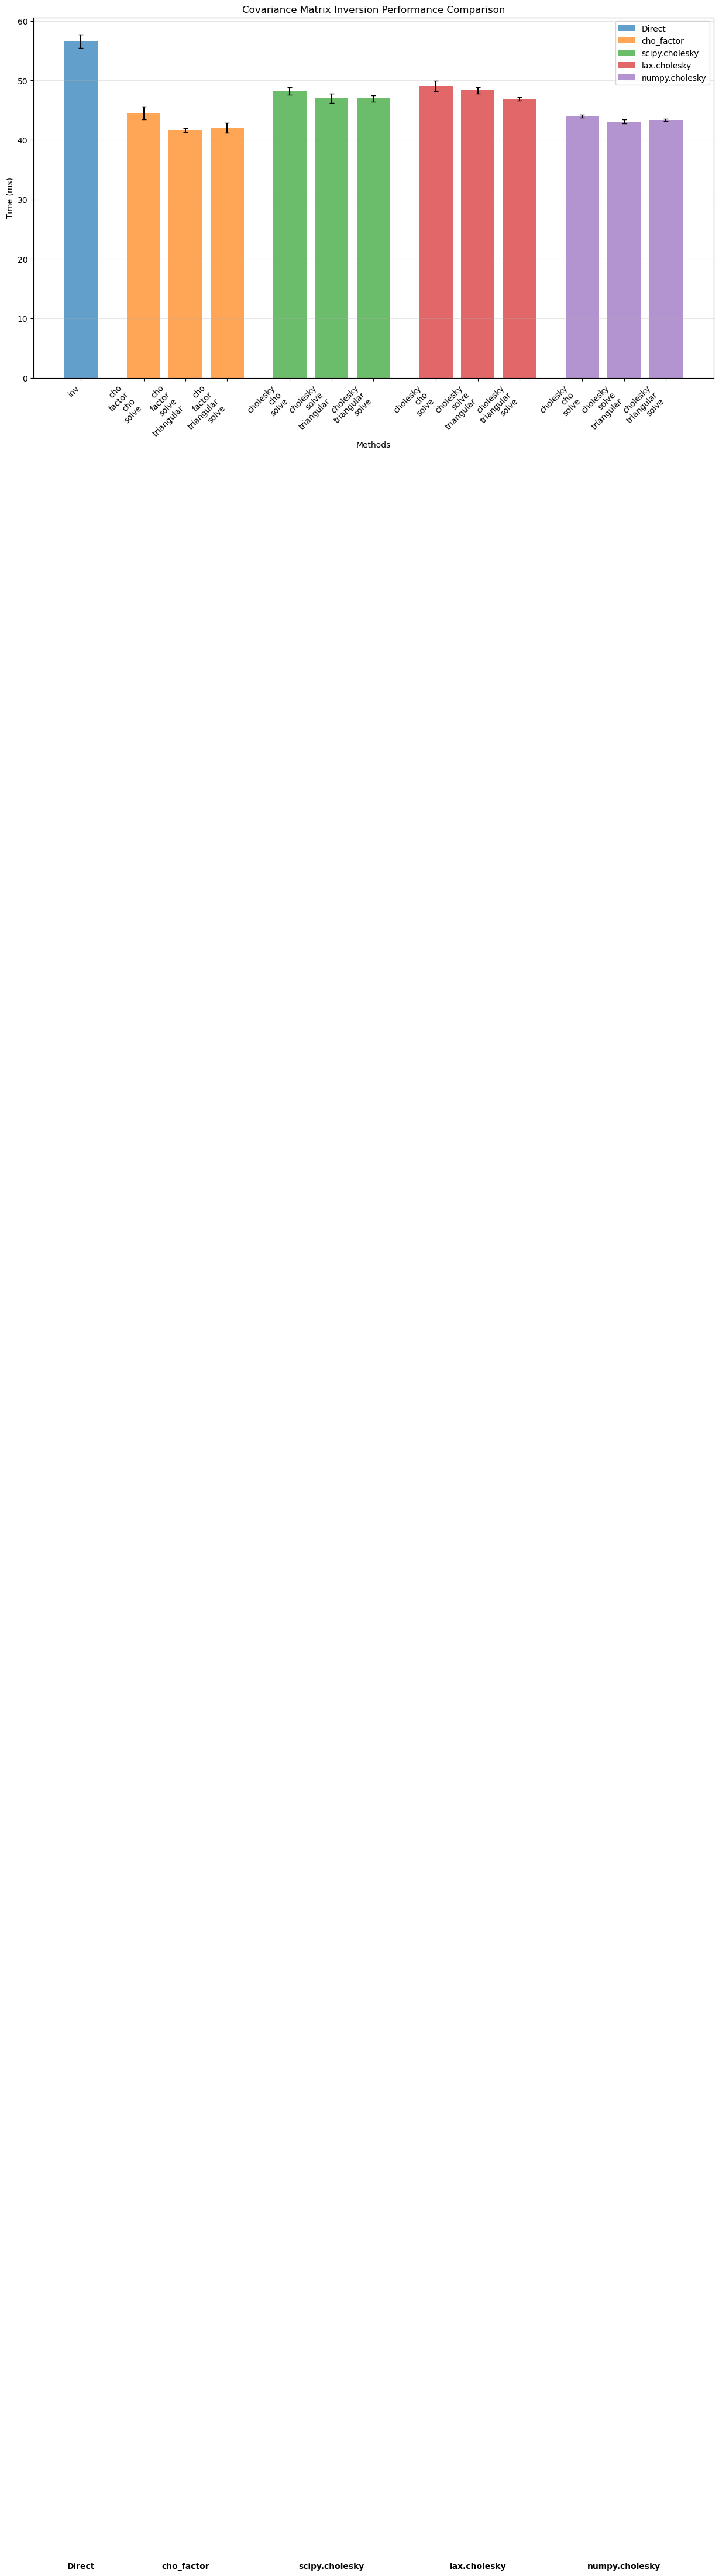

In [50]:
# Create performance comparison plot
fig, ax = plt.subplots(figsize=(15, 8))

# Group methods by decomposition type
decomposition_groups = {
    'Direct': ['numpy_inv'],
    'cho_factor': [
        'scipy_cho_factor_scipy_cho_solve',
        'scipy_cho_factor_scipy_solve_triangular', 
        'scipy_cho_factor_lax_triangular_solve'
    ],
    'scipy.cholesky': [
        'scipy_cholesky_scipy_cho_solve',
        'scipy_cholesky_scipy_solve_triangular',
        'scipy_cholesky_lax_triangular_solve'
    ],
    'lax.cholesky': [
        'lax_cholesky_scipy_cho_solve',
        'lax_cholesky_scipy_solve_triangular',
        'lax_cholesky_lax_triangular_solve'
    ],
    'numpy.cholesky': [
        'numpy_cholesky_scipy_cho_solve',
        'numpy_cholesky_scipy_solve_triangular',
        'numpy_cholesky_lax_triangular_solve'
    ]
}

# Colors for each group
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Prepare data for plotting
x_pos = 0
x_positions = []
group_positions = []
group_labels = []

for i, (group_name, methods) in enumerate(decomposition_groups.items()):
    group_start = x_pos
    group_methods = []
    
    for method in methods:
        if method in timing_results:
            group_methods.append(method)
            x_positions.append(x_pos)
            x_pos += 1
    
    if group_methods:
        group_positions.append(group_start + (len(group_methods) - 1) / 2)
        group_labels.append(group_name)
    
    x_pos += 0.5  # Space between groups

# Plot bars
for i, method in enumerate([method for group_methods in decomposition_groups.values() 
                           for method in group_methods if method in timing_results]):
    if method in timing_results:
        # Find which group this method belongs to
        group_idx = 0
        for j, (group_name, methods) in enumerate(decomposition_groups.items()):
            if method in methods:
                group_idx = j
                break
        
        mean_time = timing_results[method]['mean']
        std_time = timing_results[method]['std']
        
        bar = ax.bar(x_positions[i], mean_time, yerr=std_time, 
                    capsize=3, color=colors[group_idx], alpha=0.7)

# Customize plot
ax.set_xlabel('Methods')
ax.set_ylabel('Time (ms)')
ax.set_title('Covariance Matrix Inversion Performance Comparison')
ax.set_xticks(x_positions)

# Create method labels (shortened for readability)
method_labels = []
for method in [method for group_methods in decomposition_groups.values() 
               for method in group_methods if method in timing_results]:
    if method in timing_results:
        # Shorten labels for better readability
        label = method.replace('scipy_', '').replace('lax_', '').replace('numpy_', '')
        label = label.replace('_', '\n')
        method_labels.append(label)

ax.set_xticklabels(method_labels, rotation=45, ha='right')

# Add group labels
for pos, label in zip(group_positions, group_labels):
    ax.text(pos, -0.1 * ax.get_ylim()[1], label, ha='center', va='top', 
            fontweight='bold', transform=ax.get_xaxis_transform())

# Add grid for better readability
ax.grid(True, alpha=0.3, axis='y')

# Add legend
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colors[i], alpha=0.7) 
                  for i, group in enumerate(group_labels)]
ax.legend(legend_elements, group_labels, loc='upper right')

plt.tight_layout()
plt.show()

In [51]:
# Print summary statistics
print("\\nPerformance Summary:")
print("=" * 50)
for method, stats in sorted(timing_results.items(), key=lambda x: x[1]['mean']):
    print(f"{method:45s}: {stats['mean']:6.2f} ± {stats['std']:5.2f} ms")

# Find fastest method
fastest_method = min(timing_results.items(), key=lambda x: x[1]['mean'])
print(f"\\nFastest method: {fastest_method[0]} ({fastest_method[1]['mean']:.2f} ms)")

\nPerformance Summary:
scipy_cho_factor_scipy_solve_triangular      :  41.60 ±  0.37 ms
scipy_cho_factor_lax_triangular_solve        :  41.98 ±  0.86 ms
numpy_cholesky_scipy_solve_triangular        :  43.08 ±  0.35 ms
numpy_cholesky_lax_triangular_solve          :  43.33 ±  0.19 ms
numpy_cholesky_scipy_cho_solve               :  43.97 ±  0.28 ms
scipy_cho_factor_scipy_cho_solve             :  44.51 ±  1.08 ms
lax_cholesky_lax_triangular_solve            :  46.87 ±  0.26 ms
scipy_cholesky_lax_triangular_solve          :  46.93 ±  0.50 ms
scipy_cholesky_scipy_solve_triangular        :  46.94 ±  0.78 ms
scipy_cholesky_scipy_cho_solve               :  48.20 ±  0.63 ms
lax_cholesky_scipy_solve_triangular          :  48.31 ±  0.57 ms
lax_cholesky_scipy_cho_solve                 :  49.00 ±  0.88 ms
numpy_inv                                    :  56.59 ±  1.12 ms
\nFastest method: scipy_cho_factor_scipy_solve_triangular (41.60 ms)
